In [1]:
## ======= ##
## IMPORTS ##
## ======= ##

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import os
import dask
import dask.array
import math

import datetime

from collections import Counter

import pystac_client
from pystac.extensions.projection import ProjectionExtension as proj

import planetary_computer
import rasterio
import rasterio.features
from rasterio.features import rasterize

import stackstac
import pyproj

import dask.diagnostics

from shapely.geometry import box
from shapely.ops import transform

from scipy.ndimage import binary_propagation
from scipy.ndimage import label

In [13]:
## ========= ##
## FUNCTIONS ##
## ========= ##

## FUNCTION TO DEFINE BOUNDING BOX AROUND A GIVEN CENTROID
def bounds_latlon_around(center_lon, center_lat, side_m=10000):
    """
    center_lon, center_lat : centroid in decimal degrees (EPSG:4326)
    side_m                 : length of box side in meters (default 10 km)
    returns                 : (minx, miny, maxx, maxy) in lon/lat
    """
    
    # FIND BEST CRS FOR CENTROID
    def best_crs_for_point(lon, lat):
        """
        Choose a projected CRS (EPSG) that minimizes distortion
        for a small box around (lon, lat).

        - |lat| ≥ 60° → Polar Stereographic (EPSG:3413 North / 3031 South)
        - else         → UTM zone based on lon

        Returns a pyproj.CRS object.
        """
        if lat >= 60:
            # Arctic Polar Stereographic
            return pyproj.CRS.from_epsg(3413)
        elif lat <= -60:
            # Antarctic Polar Stereographic
            return pyproj.CRS.from_epsg(3031)
        else:
            # UTM
            zone_number = int(math.floor((lon + 180) / 6) + 1)
            is_south   = lat < 0
            # Construct a PROJ string for UTM:
            proj4 = (
                f"+proj=utm +zone={zone_number} "
                f"+{'south' if is_south else 'north'} +datum=WGS84 +units=m +no_defs"
            )
            return pyproj.CRS.from_proj4(proj4)
    
    # SET UP TRANSFORMERS
    centroid = (center_lon, center_lat)
    epsg_code = int(best_crs_for_point(*centroid).to_authority()[1])
    print(f"epsg for bounds_latlon: {epsg_code}")
    to_ps = pyproj.Transformer.from_crs(4326, epsg_code, always_xy=True).transform
    to_ll = pyproj.Transformer.from_crs(epsg_code, 4326, always_xy=True).transform

    # PROJECT CENTROID TO METERS
    x0, y0 = to_ps(center_lon, center_lat)

    # BUILD SQUARE AROUND CENTROID
    half = side_m / 2.0
    sq_m = box(x0 - half, y0 - half, x0 + half, y0 + half)

    # REPROJECT SQUARE BACK TO LAT/LON AND GRAB BOUNDS
    sq_ll = transform(to_ll, sq_m)
    return sq_ll.bounds

## FUNCTION FOR GENERATE A STACK FOR A GIVEN LOCATION ACROSS A DATE RANGE, EACH DAY
def timestack_gen(catalog, centroid, band_names, pix_res=10, tile_size=1024, time_range='2019-05-01/2019-09-30', normalize=True, pull_to_mem=False):
    """
    Generate a daily, multi-band image time‐stack centered on a point.

    This function:
      1. Searches a STAC catalog (Sentinel-2 L2A) for all scenes covering
         a square of size (in meters) around `centroid`
         between the dates in `time_range`.
      2. Builds a 4D xarray.DataArray (time, band, y, x) using stackstac.
      3. Resamples to a daily cadence, carrying forward the maximum
         cloud‐cover metadata for each day.
      4. Optionally applies a robust per‐band normalization (to [0, 1]).
      5. Crops to a square “tile” of `tile_size × tile_size` pixels around
         the centroid.
      6. Optionally computes into memory (with a dask progress bar).

    Parameters
    ----------
    centroid : tuple of float
        (longitude, latitude) in decimal degrees of the point of interest.
    band_names : list of str
        Sentinel-2 band names (e.g. ['B04','B03','B02','B08','B11']).
    tile_size : int, optional
        Size of the output tile in pixels (square) (default: 512).
    time_range : str, optional
        ISO8601 date range “YYYY-MM-DD/YYYY-MM-DD” for imagery search
        (default: '2019-05-01/2019-09-30').
    normalize : bool, optional
        If True, apply a robust (median/IQR) normalization to each band
        so values are scaled into [0,1] (default: True).
    pull_to_mem : bool, optional
        If True, triggers `timestack.compute()` and returns an in-memory
        xarray.DataArray; otherwise returns a lazy dask-backed DataArray
        (default: False).

    Returns
    -------
    xarray.DataArray
        DataArray of shape (time, band, tile_size, tile_size). Coordinates
        are:
          - time: daily steps over `time_range`
          - band: the requested `band_names`
          - y, x: UTM coordinates of the tile

    Notes
    -----
    - Requires `stackstac`, `xarray`, `dask`, and a STAC `catalog` in scope.
    - Assumes `catalog` has been defined globally or imported.
    - CRS for reprojection is taken from the first item in the search.
    """
    
    # SEARCH IMAGERY CATALOG FOR ITEMS MATCHING LOCATION AND DATE RANGE
    bounds_latlon = bounds_latlon_around(*centroid, side_m=pix_res*tile_size*1.1)
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bounds_latlon,
        datetime=time_range,
        query={"eo:cloud_cover": {"lt": 100}} )
    items = search.item_collection()
    
    # CREATE THE STACK
    stack = stackstac.stack(items, 
                            epsg=proj.ext(items[0]).epsg, 
                            assets=['B04','B03','B02', 'B08', 'B11'],
                            bounds_latlon=bounds_latlon, 
                            resolution=10,
                            chunksize=(1, 1, 4096, 4096),
                            )
    
    # SAMPLE DAILY, PRESERVING CLOUD COVER IN THE METADATA
    stack_daily = stack.resample(time="D").mean("time", keep_attrs=True)
    cc_da = xr.DataArray(
        np.array([item.properties["eo:cloud_cover"] for item in items]),
        coords={"time": stack.time},
        dims=["time"])
    start, end = time_range.split("/")
    full_days = pd.date_range(start, end, freq="D")
    stack_daily = stack_daily.reindex(time=full_days, fill_value=np.nan)
    daily_cc = cc_da.resample(time="D").max()
    daily_cc = daily_cc.reindex(time=full_days, fill_value=np.nan)
    stack_daily = stack_daily.assign_coords(eo_cloud_cover=daily_cc)
    # print(f"stack_daily shape: {stack_daily.shape}")
    
    # IF NORMALIZING
    if normalize:
        def combo_scaler(x, range_max=1):
            median_x = np.nanmedian(x)
            iqr_x = np.nanpercentile(x,75) - np.nanpercentile(x,25)
            robust_x = ((x-median_x)/iqr_x)
            return ((robust_x - np.nanmin(robust_x)) / (np.nanmax(robust_x) - np.nanmin(robust_x))) * range_max
        
        stack_rechunk = stack_daily.chunk({'y': -1, 'x': -1})
        stack_daily = xr.apply_ufunc(
            combo_scaler,            
            stack_rechunk,                   
            input_core_dims=[['y','x']],
            output_core_dims=[['y','x']],
            vectorize=True,       
            dask='parallelized',
            output_dtypes=[float],
            kwargs={'range_max':1},
            keep_attrs=True)

    # CROP TILES TO DESIRED SIZE
    pix_res = 10 #[m/pix]
    buffer = tile_size * pix_res/2 #[m]
    x_utm, y_utm = pyproj.Proj(stack.crs)(*centroid)
    timestack = stack_daily.loc[..., y_utm+buffer:y_utm-buffer, x_utm-buffer:x_utm+buffer]
    
    # TRACK PERCENT OF PIXELS THAT ARE NAN AND STORE AS NEW COORDINATE IN DATAARRAY
    nan_counts = timestack.isnull().sum(dim=('band', 'y', 'x'))
    total = len(band_names) * tile_size * tile_size
    pct_nans = (nan_counts / total) * 100
    timestack = timestack.assign_coords(pct_nans=('time', pct_nans.values))
    
    # PULL STACK INTO MEMORY
    if pull_to_mem:
        stack_to_pull = timestack
        print(f"pulling stack into memory, shape will be: {timestack.shape}")
        with dask.diagnostics.ProgressBar():
            timestack_mem = stack_to_pull.compute()
        print(f"shape of stack in memory: {timestack_mem.shape}")
        return timestack_mem
    else:
        print(f"timestack (not in mem) shape: {timestack.shape}\n")
        return timestack

In [14]:
## ========= ##
## RUN BLOCK ##
## ========= ##

## CONNECT TO MICROSOFT PLANETARY COMPUTER
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,)
print(f"connected to Microsoft Planetary Computer")

# DECIDE WHETHER TO NORMALIZE THE IMAGERY UPON COMPLIING OR NOT
normalize = False

# BOUNDING BOX AROUND LAKE CENTROID
centroid = (-122.45, 37.83)
# centroid = (-122.45957, 37.80539) # CHRISSY FIELD MARSH
# centroid = (-49.495, 68.725) # NORTH LAKE

# SPECIFY TIME RANGE
time_range = '2019-05-01/2019-09-30'

# SPECIFY IMAGERY BANDS
band_names = ["B04",  # red (665 nm)
              "B03",  # green (560 nm)
              "B02",  # blue (490 nm)
              "B08",  # NIR (842 nm)
              "B11"]  # SWIR1 (1610 nm)

# CALL FUNCTION TO GENERATE TIMESTACK
timestack = timestack_gen(catalog, centroid, band_names, pix_res=10, tile_size=1024, time_range='2019-05-01/2019-09-30', normalize=True, pull_to_mem=True)

# SAVE STACK TO DISK OR MAYBE NEED TO STACK THESE ALL TOGETHER ACROSS LAKES INTO ONE FILE???

connected to Microsoft Planetary Computer
epsg for bounds_latlon: 32610
pulling stack into memory, shape will be: (153, 5, 1024, 1024)
[########################################] | 100% Completed | 38.88 s
shape of stack in memory: (153, 5, 1024, 1024)


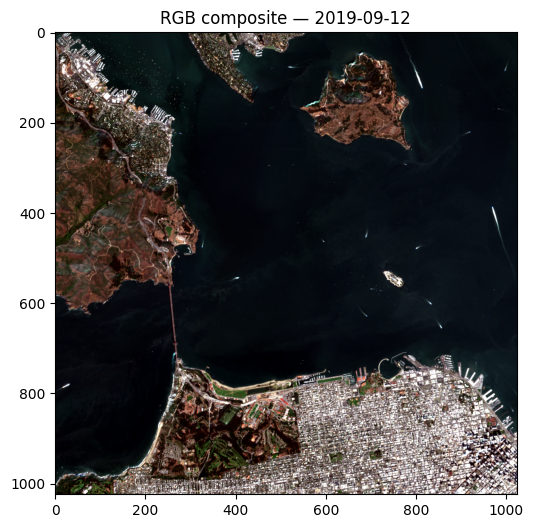

In [15]:
## ======== ##
## PLOTTING
## ======== ##
def linear_stretch_rgb(rgb, pmin=2, pmax=98):
    out = np.empty_like(rgb)
    for i in range(3):
        band = rgb[..., i]
        lo, hi = np.nanpercentile(band, (pmin, pmax))
        out[..., i] = np.clip((band - lo) / (hi - lo), 0, 1)
    return out
tslice = timestack.sel(time="2019-09-12")

# 2) grab the 3 bands you want (ensure order is R,G,B):
rgb_bands = ["B04","B03","B02"]
r = tslice.sel(band=rgb_bands[0]).values
g = tslice.sel(band=rgb_bands[1]).values
b = tslice.sel(band=rgb_bands[2]).values

# 3) stack into a height×width×3 array:
rgb = np.stack([r, g, b], axis=-1)
rgb_st = linear_stretch_rgb(rgb, pmin=2, pmax=98)

# 4) plot (assuming your data are scaled [0,1]; if not, adjust vmin/vmax):
plt.figure(figsize=(6,6))
plt.imshow(rgb_st)
plt.title(f"RGB composite — {str(tslice.time.values)[:10]}")
plt.show()

In [16]:
timestack



<xarray.DataArray 'stackstac-e54ded6f23fb618075f6faacb372d819' (time: 153,
                                                                band: 5,
                                                                y: 1024, x: 1024)> Size: 6GB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]])
Coordinates: (12/21)
  * band                                     (band) <U3 60B 'B04' ... 'B11'
  * x                                        (x) float64 8kB 5.433e+05 ... 5....
  * y                                        (y) float64 8kB 4.192e+06 ... 4....
  * time                                     (time) datetime64[ns] 1kB 2019-0...
    s2:datatake_type                         <U8 32B 'INS-NOBS'
    constellation                            <U10 40B 'Sentinel 2'
    ...                                       ...
    common_name                              (band) <U6 120B 'red' ... 'swir16'
    center_wavelength                        (band) float64 40B 0.665 ... 1.61
    full_width_half_max                      (band) float64 40B 0.038 ... 0.143
    epsg                                     int64 8B 32610
    eo_cloud_cover                           (time) float64 1kB nan nan ... nan
    pct_nans                                 (time) float64 1kB 100.0 ... 100.0
Attributes:
    spec:        RasterSpec(epsg=32610, bounds=(542700, 4181390, 554110, 4192...
    crs:         epsg:32610
    transform:   | 10.00, 0.00, 542700.00|\n| 0.00,-10.00, 4192800.00|\n| 0.0...
    resolution:  10